In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Helper for loading baseline (fixed for value stripping and error handling)
def load_baseline(file_path, data_dict):
    current_label = None
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            # Check for label start
            if 'Schmalz' in file_path:
                label_match = re.match(r'^([A-Z_]+)\s*=\s*\[?', line)
            else:
                label_match = re.match(r'^([A-Za-z_]+)\s*=\s*\[?', line)
            
            if label_match:
                current_label = label_match.group(1)
                data_dict[current_label] = []
                continue
                
            # Check for end of list (or just skip if no current_label)
            if line.endswith(']'):
                current_label = None
                continue

            if current_label:
                vals = line.split(';')
                if len(vals) == 2:
                    try:
                        x, y = map(float, [v.strip() for v in vals])
                        data_dict[current_label].append((x, y))
                    except ValueError:
                        continue



# In Jupyter notebooks, to reload a function after editing its code, simply re-run the cell containing the function definition.
# This will overwrite the previous version of the function with the new one.

def plot_three_baselines_joint(baseline_data, baseline_data_2, baseline_data_3, stance_to_swing_switch, mass_baseline, mass_baseline_2, mass_baseline_3, joint=None):
    # Use the existing ax if available
    global ax
    fig, ax = plt.subplots(figsize=(10, 6))
    # Plot Banks et al. (baseline 1)
    for label, points in baseline_data.items():
        if joint and joint.lower() in label.lower():
            label_lower = label.lower()
            if 'ankle' in label_lower:
                label_lower = label_lower.replace('ankle', 'foot')
            if 'intact' not in label.lower():
                if points:
                    xs, ys = zip(*points)
                    ys = np.array(ys) *-1/ mass_baseline
                    ax.plot(xs, ys, marker='o', linestyle='-', color='black', label="Banks et al.")

    # Plot Turcot et al. (baseline 2)
    for label, points in baseline_data_2.items():
        if joint and joint.lower() in label.lower():
            label_lower = label.lower()
            if 'ankle' in label_lower:
                label_lower = label_lower.replace('ankle', 'foot')
            if points:
                xs, ys = zip(*points)
                ys = np.array(ys) *-1/ mass_baseline_2
                ax.plot(xs, ys, marker='o', linestyle='--', color='grey', label="Turcot et al.")

    # Plot Schmalz et al. (baseline 3)
    if 'knee' in joint.lower():
        for label, points in baseline_data_3.items():
            label_lower = label.lower()
            # if joint and joint.lower() in label.lower():
            #     label_lower = label.lower()
            #     if 'knee' in label_lower:
            #         label_lower = label_lower.replace('knee', 'thigh')
            if 'opt' in label_lower and points:
                xs, ys = zip(*points)
                ys = np.array(ys)/ mass_baseline_3
                xs = np.array(xs)
                xs_scaled = xs/ 100.0 * stance_to_swing_switch+2
                ax.plot(xs_scaled, ys, marker='o', linestyle=':', color='blue', label="Schmalz OPT")
                ax.axvline(stance_to_swing_switch, color='red', linestyle=':', linewidth=2, label="Stance-to-Swing Transition")

    ax.legend()
    ax.set_xlabel("Gait Cycle (%)")
    ax.set_ylabel("Normalized Moment")
    ax.set_title(f"Baseline Kinetic Data Comparison: {joint.capitalize() if joint else ''}")
    if ax.figure:
        ax.figure.tight_layout()
        ax.figure.show()



def extract_gait_cycle_extrema(baseline_data, mass_baseline, joint='knee'): 
    print(f"Extrema for joint: {joint.capitalize()}")
    for label, points in baseline_data.items():
        if joint and joint.lower() in label.lower():
            if points:
                xs, ys = zip(*points)
                ys = np.array(ys) / mass_baseline #*-1/ mass_baseline
                max_idx = np.argmax(ys) #[:len(ys)//2])  # Max in first half
                min_idx = np.argmin(ys[:len(ys)//2]) #[:len(ys)//2])
                min_idx_2 = np.argmin(ys[len(ys)//2:]) + len(ys)//2  # Min in second half
                print(f"{label} - Max: ({xs[max_idx]}, {ys[max_idx]}), 1. Min: ({xs[min_idx]}, {ys[min_idx]}), 2. Min: ({xs[min_idx_2]}, {ys[min_idx_2]})")


def extract_gait_cycle_extrema_Schmalz(baseline_data, mass_baseline, joint='knee', stance_to_swing_switch=None):
    print(f"Extrema for joint: {joint.capitalize()}")
    for label, points in baseline_data.items():
        if 'OPT' in label:
            if points:
                xs, ys = zip(*points)
                xs = np.array(xs)
                xs_scaled = xs/ 100.0 * stance_to_swing_switch+2
                ys = np.array(ys) / mass_baseline
                max_idx = np.argmax(ys)
                min_idx = np.argmin(ys[:len(ys)//2])
                min_idx_2 = np.argmin(ys[len(ys)//2:]) + len(ys)//2  # Min in second half
                print(f"{label} - Max: ({xs_scaled[max_idx]}, {ys[max_idx]}), 1. Min: ({xs_scaled[min_idx]}, {ys[min_idx]}), 2. Min: ({xs_scaled[min_idx_2]}, {ys[min_idx_2]})")


# Implement a method that takes the 2 baseline data and colors the area between them in grey and plots them on the edge of the area
def plot_baseline_area(baseline_data_1, baseline_data_2, mass_baseline_1, mass_baseline_2, joint=None):
    global ax
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Extract points for baseline 1
    for label, points in baseline_data_1.items():
        if joint and joint.lower() in label.lower():
            if 'intact' not in label.lower():
                if points:
                    xs1, ys1 = zip(*points)
                    ys1 = np.array(ys1) *-1/ mass_baseline_1
                    ax.plot(xs1, ys1, marker='o', linestyle='-', color='black', label="Banks et al.")
    
    # Extract points for baseline 2
    for label, points in baseline_data_2.items():
        if joint and joint.lower() in label.lower():
            if points:
                xs2, ys2 = zip(*points)
                ys2 = np.array(ys2) *-1/ mass_baseline_2
                ax.plot(xs2, ys2, marker='o', linestyle='--', color='grey', label="Turcot et al.")
    
    # Ensure both baselines have the same x values for area filling
    # Ensure both baselines have the same x values for area filling
    if 'xs1' in locals() and 'xs2' in locals():
        xs1 = np.array(xs1)
        xs2 = np.array(xs2)
        ys1 = np.array(ys1)
        ys2 = np.array(ys2)
        # Interpolate ys2 to xs1 if lengths or x-values differ
        if not np.array_equal(xs1, xs2):
            ys2_interp = np.interp(xs1, xs2, ys2)
            ax.fill_between(xs1, ys1, ys2_interp, color='lightgrey', alpha=0.5)
        else:
            ax.fill_between(xs1, ys1, ys2, color='lightgrey', alpha=0.5)
    
    ax.legend()
    ax.set_xlabel("Gait Cycle (%)")
    ax.set_ylabel("Normalized Moment")
    ax.set_title(f"Baseline Kinetic Data Comparison Area: {joint.capitalize() if joint else ''}")
    if ax.figure:
        ax.figure.tight_layout()
        ax.figure.show()

# Compare SACH vs Dynamic 

Schmalz et al. use Dynamic vs Simulation SACH
- Turcot, Katia, et al. "Comparison of the International Committee of the Red Cross foot with the solid ankle cushion heel foot during gait: a randomized double-blind study." Archives of Physical Medicine and Rehabilitation 94.8 (2013): 1490-1497.
- Banks, Brevin P., et al. "Low-cost prosthetic feet for underserved populations: A comparison of gait analysis and mechanical stiffness." Prosthetics and Orthotics International 47.4 (2023): 399-406.
- Schmalz, Thomas, Siegmar Blumentritt, and Rolf Jarasch. "Energy expenditure and biomechanical characteristics of lower limb amputee gait:: The influence of prosthetic alignment and different prosthetic components." Gait & posture 16.3 (2002): 255-263.


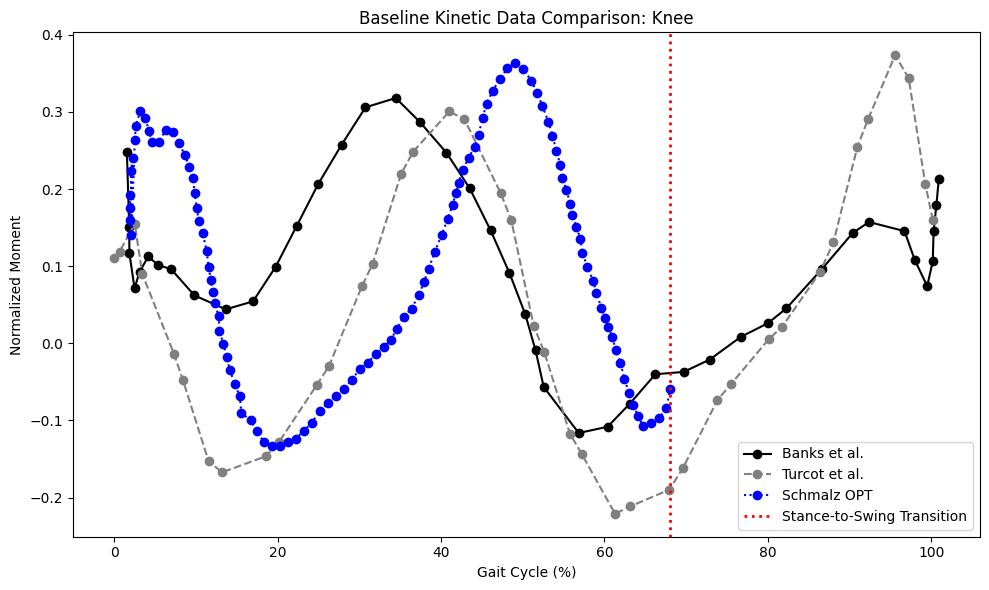

In [11]:
# kinematic_baseline_file = '/home/nadinebadie/loco-mujoco/prosthesis_evaluation/Kinematics_Banks_2022.csv'
# kinematic_baseline_file_2 ='/home/nadinebadie/loco-mujoco/prosthesis_evaluation/Kinetmatics_Turcot_2013.csv'
kinetic_baseline_file = '/home/nadinebadie/loco-mujoco/prosthesis_evaluation/Kinetics_Banks_2022.csv'
kinetic_baseline_file_2 = '/home/nadinebadie/loco-mujoco/prosthesis_evaluation/Kinetics_Turcot_2013.csv'
kinetic_baseline_file_3 = '/home/nadinebadie/loco-mujoco/prosthesis_evaluation/Alignment_Data_Schmalz_2002.csv'
mass_baseline = 97.5
mass_baseline_2 = 1 #75#*9.81
mass_baseline_3 = 85

stance_to_swing_switch = 68 # 70% of gait cycle

baseline_data = {}
baseline_data_2 = {}
baseline_data_3 = {}

load_baseline(kinetic_baseline_file, baseline_data)
load_baseline(kinetic_baseline_file_2, baseline_data_2)
load_baseline(kinetic_baseline_file_3, baseline_data_3)

# Example usage within your existing plotting function
plot_three_baselines_joint(baseline_data, baseline_data_2, baseline_data_3, stance_to_swing_switch, mass_baseline, mass_baseline_2, mass_baseline_3, joint='knee')

In [12]:
extract_gait_cycle_extrema(baseline_data, mass_baseline, joint='knee')

extract_gait_cycle_extrema(baseline_data_2, mass_baseline_2, joint='knee')

extract_gait_cycle_extrema_Schmalz(baseline_data_3, mass_baseline_3, joint='knee', stance_to_swing_switch=stance_to_swing_switch)

Extrema for joint: Knee
Knee - Max: (56.85969043045978, 0.11628378408019163), 1. Min: (34.47442322901361, -0.3180732600732598), 2. Min: (100.92332165856959, -0.21329234278695344)
Knee_CF_Intact - Max: (57.37808609196696, 0.1256845605492317), 1. Min: (2.3810190938876588, -0.26557987322059157), 2. Min: (101.2060829284826, -0.27175556579149357)
Extrema for joint: Knee
Knee - Max: (61.30424799081516, 0.22102656669443688), 1. Min: (41.034443168771524, -0.30070119411274643), 2. Min: (95.57864523536168, -0.3735004165509579)
Extrema for joint: Knee
OPT - Max: (49.12, 0.3630561047948591), 1. Min: (19.28228571428571, -0.13346515076618878), 2. Min: (64.77257142857141, -0.10768042511122092)


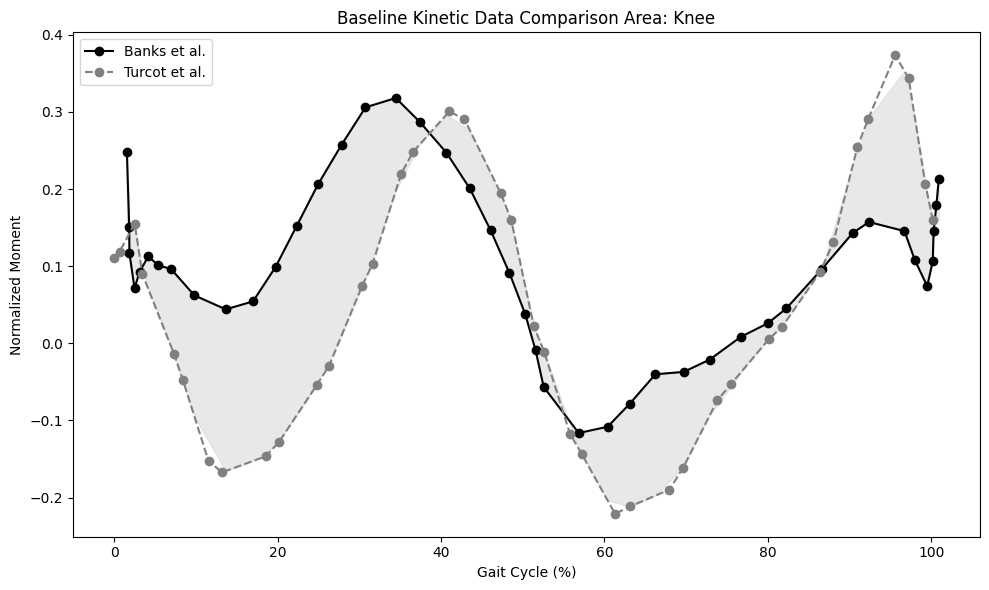

In [31]:
# Plot baseline area between two baselines
plot_baseline_area(baseline_data, baseline_data_2, mass_baseline, mass_baseline_2, joint='knee')

# COMPARE SACH VS ESR 


Kobayashi Alignment paper use ESR vs Simulation SACH 
- Kobayashi et al. have paper with SACH: Kobayashi, Toshiki, et al. "Socket reaction moments in transtibial prostheses during walking at clinically perceived optimal alignment." Prosthetics and orthotics International 40.4 (2016): 503-508.
- ESR:  Kobayashi, Toshiki, et al. "Effect of alignment changes on socket reaction moments while walking in transtibial prostheses with energy storage and return feet." Clinical Biomechanics 29.1 (2014): 47-56.

In [ ]:
def load_baseline_pylon(file_path, data_dict):
    current_label = None
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            label_match = re.match(r'^([A-Za-z+\-_]+)\s*=\s*\[?', line)
            if label_match: 
                current_label = label_match.group(1)
                data_dict[current_label] = []
                continue
            if current_label:
                vals = line.split(';')
                if len(vals) == 2:
                    try:
                        x, y = map(float, vals)
                        data_dict[current_label].append((x, y))
                    except ValueError:
                        continue  


def plot_pylon_torque_baselines(baseline_data, baseline_data_2, plane = 'sagittal'):
    global ax
    fig, ax = plt.subplots(figsize=(10, 6))
    # Plot from baseline_data: mean and std for the given plane
    for label, points in baseline_data.items():
        if plane.lower() in label.lower() and 'std' not in label.lower():
            # Find std label
            std_label_p = f"{plane.capitalize()}+std"
            std_label_m = f"{plane.capitalize()}-std"
            if points:
                xs, ys = zip(*points)
                xs = np.array(xs) * 100  # Convert from 0-1 to 0-100 for consistency
                ys = np.array(ys)
                # Sort by xs
                sort_idx = np.argsort(xs)
                xs = xs[sort_idx]
                ys = ys[sort_idx]
                ax.plot(xs, ys, marker='o', linestyle='-', color='grey', label=f"SACH Mean")
                # Plot std if available
                if std_label_p in baseline_data and std_label_m in baseline_data:
                    xs_std_p, ys_std_p = zip(*baseline_data[std_label_p])
                    xs_std_m, ys_std_m = zip(*baseline_data[std_label_m])
                    xs_std_p = np.array(xs_std_p) * 100
                    xs_std_m = np.array(xs_std_m) * 100
                    ys_std_p = np.array(ys_std_p)
                    ys_std_m = np.array(ys_std_m)
                    # Sort std data by x before plotting
                    sort_idx_p = np.argsort(xs_std_p)
                    sort_idx_m = np.argsort(xs_std_m)
                    xs_std_p = xs_std_p[sort_idx_p]
                    ys_std_p = ys_std_p[sort_idx_p]
                    xs_std_m = xs_std_m[sort_idx_m]
                    ys_std_m = ys_std_m[sort_idx_m]
                    # Interpolate if needed
                    if len(xs_std_p) != len(ys_std_m):
                        ys_std_m_interp = np.interp(xs_std_p, xs_std_m, ys_std_m)
                    else:
                        ys_std_m_interp = ys_std_m
                    if len(xs_std_p) != len(ys_std_p):
                        ys_std_p_interp = np.interp(xs_std_p, xs_std_p, ys_std_p)
                    else:
                        ys_std_p_interp = ys_std_p
                    ax.fill_between(xs_std_p, ys_std_m_interp, ys_std_p_interp, color='grey', alpha=0.2, label=f"SACH ± STD")

    # Plot from baseline_data_2: only Sagittal or Coronal depending on plane
    for label, points in baseline_data_2.items():
        if plane.lower() in label.lower():
            if points:
                xs, ys = zip(*points)
                xs = np.array(xs)
                ys = np.array(ys)
                # Sort by xs
                sort_idx = np.argsort(xs)
                xs = xs[sort_idx]
                ys = ys[sort_idx]
                ax.plot(xs, ys, marker='o', linestyle='--', color='black', label=f"ESR Mean")

    ax.legend()
    ax.set_xlabel("Gait Cycle (%)")
    ax.set_ylabel("Normalized Moment")
    ax.set_title(f"Pylon Torque Baseline Kinetic Data Comparison: {plane.capitalize()}")
    if ax.figure:
        ax.figure.tight_layout()
        ax.figure.show()


# Method to extract extrema for pylon data
def extract_extrema_pylon(data, plane):
    for label, points in data.items():
        if points:
            xs, ys = zip(*points)
            ys = np.array(ys)
            max_idx = np.argmax(ys)
            min_idx = np.argmin(ys)
            if plane == 'sagittal' and plane in label.lower():
                # at 45% gait cycle
                xs_arr = np.array(xs)
                ys_arr = np.array(ys)
                # Determine if xs is in 0-1 or 0-100 range
                if xs_arr.max() > 2:
                    percent_45 = 45
                else:
                    percent_45 = 0.45
                # Ensure xs is sorted for interpolation
                if xs_arr[0] > xs_arr[-1]:
                    xs_arr = xs_arr[::-1]
                    ys_arr = ys_arr[::-1]
                # Sort xs and ys by xs before extracting/interpolating
                sort_idx = np.argsort(xs_arr)
                xs_arr = xs_arr[sort_idx]
                ys_arr = ys_arr[sort_idx]
                if xs_arr[0] <= percent_45 <= xs_arr[-1]:
                    y_45 = np.interp(percent_45, xs_arr, ys_arr)
                    print(f"{label} - 45% Gait Cycle: ({percent_45}, {y_45})")
                # Get zero crossing time if it exists
                ys_sign = np.sign(ys_arr)
                zero_crossings = np.where(np.diff(ys_sign))[0]
                for idx in zero_crossings:
                    # Interpolate zero crossing between xs_arr[idx] and xs_arr[idx+1]
                    x0, x1 = xs_arr[idx], xs_arr[idx+1]
                    y0, y1 = ys_arr[idx], ys_arr[idx+1]
                    if y1 != y0:
                        zero_x = x0 - y0 * (x1 - x0) / (y1 - y0)
                        print(f"{label} - Zero crossing at: ({zero_x})")
            elif plane == 'coronal' and plane in label.lower():
                # at 30% & 75% gait cycle, interpolate if needed
                xs_arr = np.array(xs)
                ys_arr = np.array(ys)
                # Determine if xs is in 0-1 or 0-100 range
                if xs_arr.max() > 2:
                    percent_30 = 30
                    percent_75 = 75
                else:
                    percent_30 = 0.30
                    percent_75 = 0.75
                # Interpolate y at percent_30 and percent_75
                # Sort xs and ys by xs before extracting/interpolating
                sort_idx = np.argsort(xs_arr)
                xs_arr = xs_arr[sort_idx]
                ys_arr = ys_arr[sort_idx]
                if xs_arr[0] > xs_arr[-1]:
                    xs_arr = xs_arr[::-1]
                    ys_arr = ys_arr[::-1]
                if xs_arr[0] <= percent_30 <= xs_arr[-1]:
                    y_30 = np.interp(percent_30, xs_arr, ys_arr)
                    print(f"{label} - 30% Gait Cycle: ({percent_30}, {y_30})")
                if xs_arr[0] <= percent_75 <= xs_arr[-1]:
                    y_75 = np.interp(percent_75, xs_arr, ys_arr)
                    print(f"{label} - 75% Gait Cycle: ({percent_75}, {y_75})")
            print(f"{label} - Max: ({xs[max_idx]}, {ys[max_idx]}), Min: ({xs[min_idx]}, {ys[min_idx]})")

Sagittal - 45% Gait Cycle: (0.45, 0.22473713828059214)
Sagittal - Zero crossing at: (0.04392713466318096)
Sagittal - Zero crossing at: (0.3340097556311507)
Sagittal - Max: (0.747601637930135, 0.7015849558822258), Min: (0.20017224453323332, -0.14035697057688945)
Sagittal+std - 45% Gait Cycle: (0.45, 0.3623708743485049)
Sagittal+std - Zero crossing at: (0.12764931985156136)
Sagittal+std - Zero crossing at: (0.24579905134819016)
Sagittal+std - Max: (0.7566033889159002, 0.8777454780361755), Min: (0.1961759367000939, -0.021712604076945086)
Sagittal-std - 45% Gait Cycle: (0.45, 0.08674354475820657)
Sagittal-std - Zero crossing at: (0.4204176772024671)
Sagittal-std - Zero crossing at: (0.9788476928375183)
Sagittal-std - Max: (0.7367119885755105, 0.5351645882485113), Min: (0.21900939568147068, -0.25274547803617575)
Coronal - Max: (0.11475551869890521, 0.018398447894942063), Min: (0.3419266632959273, -0.07746364578500944)
Coronal+std - Max: (0.15398313110466766, 0.07668648366235524), Min: (0.36

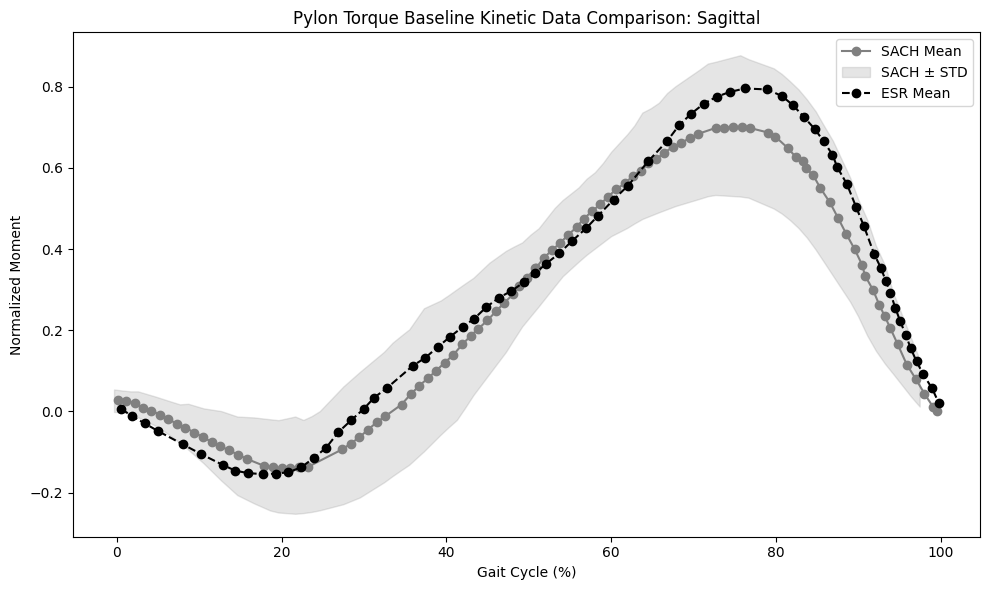

In [7]:
pylon_baseline_file = '/home/nadinebadie/loco-mujoco/prosthesis_evaluation/Kobayashi_SACH_optimalAlignment_socketMoment_2016.csv'
pylon_baseline_file_2 = '/home/nadinebadie/loco-mujoco/prosthesis_evaluation/Kinetics_Kobayashi_ESR_Alignment_2014.csv'



pylon_data = {}
pylon_data_2 = {}

load_baseline_pylon(pylon_baseline_file, pylon_data)
load_baseline(pylon_baseline_file_2, pylon_data_2)


# Example usage within your existing plotting function
plot_pylon_torque_baselines(pylon_data, pylon_data_2, plane= 'sagittal')

extract_extrema_pylon(pylon_data, plane='sagittal')
extract_extrema_pylon(pylon_data_2, plane='sagittal')

# extract_extrema_pylon(pylon_data, plane='coronal')
# extract_extrema_pylon(pylon_data_2, plane='coronal')